# Preparação do Ambiente e Base de Dados
Nesta primeira etapa, vamos importar as bibliotecas necessárias para manipulação de dados (pandas e numpy) e criação de gráficos (matplotlib). Em seguida, faremos o carregamento do arquivo CSV fornecido pela UNODC e um tratamento inicial para remover dados nulos e focar apenas na métrica de contagem absoluta ("Counts"), evitando distorções com taxas proporcionais.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminho do arquivo
caminho_arquivo = 'data_cts_intentional_homicide.csv'

# 1. Lendo o arquivo CSV original
df_counts = pd.read_csv(caminho_arquivo, skiprows=2, low_memory=False)

# 2. Criando o DataFrame limpo (Filtra apenas contagens absolutas e evita dupla contagem)
df_limpo = df_counts[
    (df_counts['Unit of measurement'] == 'Counts') &
    (df_counts['Dimension'] == 'Total') &
    (df_counts['Category'] == 'Total') &
    (df_counts['Age'] == 'Total')
].copy()

# 3. Garante que a coluna 'VALUE' é tratada como número (fundamental para as somas)
df_limpo['VALUE'] = pd.to_numeric(df_limpo['VALUE'], errors='coerce')

# Exibindo as primeiras linhas para verificar
df_limpo.head()

# Carregamento do arquivo
#df = pd.read_csv('data_cts_intentional_homicide.csv', skiprows=2, low_memory=False)

# Padronizando colunas
#df.columns = [col.capitalize() for col in df.columns]

# Filtrando contagens e convertendo valores
#df_counts = df[df['Unit of measurement'] == 'Counts'].copy()
#df_counts['Year'] = pd.to_numeric(df_counts['Year'], errors='coerce')
#df_counts['VALUE'] = pd.to_numeric(df_counts['VALUE'], errors='coerce')
#df_counts = df_counts.dropna(subset=['VALUE'])

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,ABW,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,0.0,MD
1,AIA,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,0.0,WHO/NSO/SDG/PAHO
2,ARM,Armenia,Asia,Western Asia,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,178.0,UNSDC/TransMonEE/CTS
3,ATG,Antigua and Barbuda,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,1.0,MD/PAHO/OAS/CTS
4,AUS,Australia,Oceania,Australia and New Zealand,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,374.0,MD/Eurostat/GSH 2019 Revision/CTS


1. Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?
Para responder a esta pergunta, filtramos os dados para o período de 2018 a 2022, agrupamos pelo nome do país e somamos os valores totais de homicídios. Por fim, extraímos os 10 maiores.

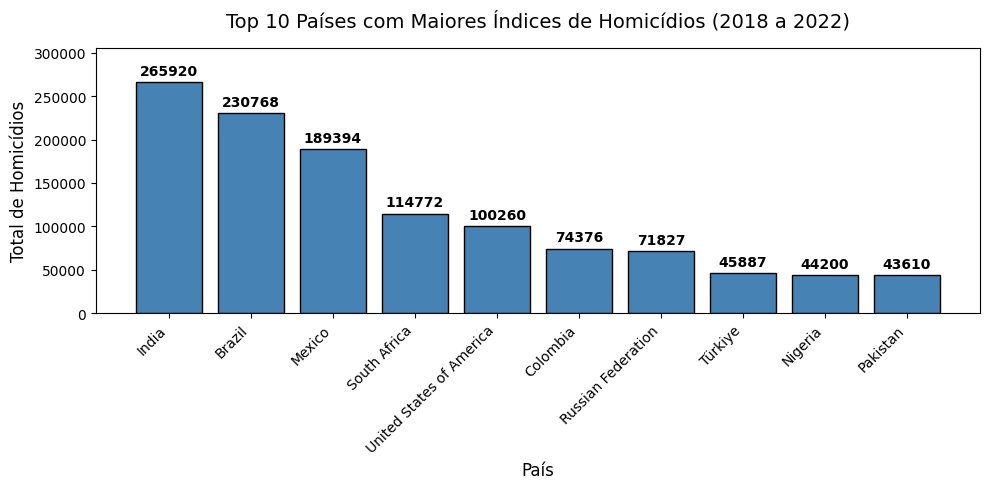

In [67]:
import matplotlib.pyplot as plt

# Filtra os dados para o período de 2018 a 2022
df_ultimos_5_anos = df_limpo[(df_limpo['Year'] >= 2018) & (df_limpo['Year'] <= 2022) & (df_limpo['Sex'] == 'Total')]
# Agrupa por país e obter os 10 maiores
top_10_paises = df_ultimos_5_anos.groupby('Country')['VALUE'].sum().nlargest(10).reset_index()

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    top_10_paises["Country"],
    top_10_paises["VALUE"],
    color="steelblue",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout
plt.title(
    "Top 10 Países com Maiores Índices de Homicídios (2018 a 2022)",
    fontsize=14,
    pad=15,
)
plt.xlabel("País", fontsize=12)
plt.ylabel("Total de Homicídios", fontsize=12)


plt.xticks(rotation=45, ha="right", fontsize=10) # Rotaciona os nomes dos países em 45 graus para não sobrepor
plt.ylim(0, top_10_paises["VALUE"].max() * 1.15) # Definindo os limites, superior com folga
plt.tight_layout()                               # Ajusta automaticamente as margens do gráfico
plt.show()                                       # Exibir o gráfico no Colab

2. Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022?
Aqui, aplicamos dois filtros simultâneos: o ano deve ser exatamente 2022 e a coluna 'Sex' deve conter a palavra 'Female'. Depois, repetimos a lógica de agrupamento e soma.

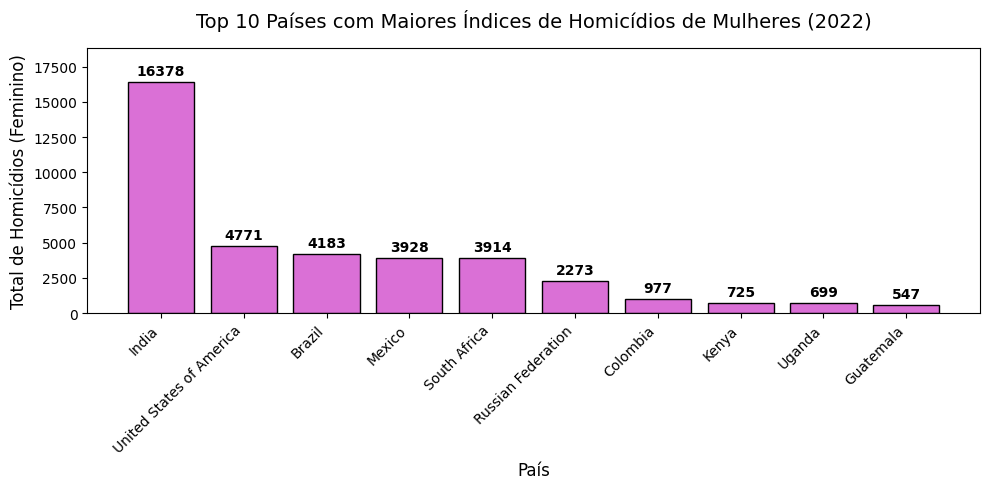

In [68]:
import matplotlib.pyplot as plt

# Filtra os dados para o ano de 2022 e sexo feminino
df_2022_fem = df_limpo[(df_limpo['Year'] == 2022) & (df_limpo['Sex'] == 'Female')]
# Agrupa por país e obter os 10 maiores
top_10_mulheres = df_2022_fem.groupby('Country')['VALUE'].sum().nlargest(10).reset_index()

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    top_10_mulheres["Country"],
    top_10_mulheres["VALUE"],
    color="orchid",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title(
    "Top 10 Países com Maiores Índices de Homicídios de Mulheres (2022)",
    fontsize=14,
    pad=15,
)
plt.xlabel("País", fontsize=12)
plt.ylabel("Total de Homicídios (Feminino)", fontsize=12)


plt.ylim(0, top_10_mulheres["VALUE"].max() * 1.15) # Definindo os limites, superior com folga
plt.xticks(rotation=45, ha="right", fontsize=10)   # Rotaciona os nomes dos países para não sobrepor
plt.tight_layout()                                 # Ajusta automaticamente as margens do gráfico
plt.show()                                         # Exibir o gráfico no Colab

3. Quais as regiões com mais homicídios?
Vamos agrupar todo o dataset histórico pela coluna 'Region' (que representa os continentes/grandes regiões) e somar os valores, ordenando do maior para o menor.

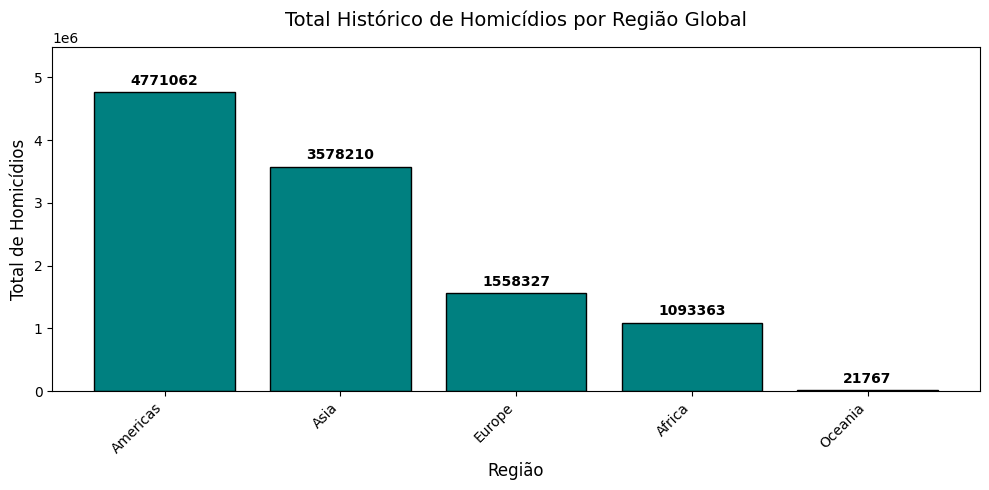

In [69]:
import matplotlib.pyplot as plt

# Filtra os dados para o sexo Total
df_totais = df_limpo[df_limpo['Sex'] == 'Total']
# Agrupa por região e ordena do maior para o menor
regioes_maiores = df_totais.groupby('Region')['VALUE'].sum().sort_values(ascending=False).reset_index()

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    regioes_maiores["Region"],
    regioes_maiores["VALUE"],
    color="teal",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title("Total Histórico de Homicídios por Região Global", fontsize=14, pad=15)
plt.xlabel("Região", fontsize=12)
plt.ylabel("Total de Homicídios", fontsize=12)

plt.ylim(0, regioes_maiores["VALUE"].max() * 1.15) # Definindo os limites, superior com folga
plt.xticks(rotation=45, ha="right", fontsize=10)   # Rotaciona os nomes das regiões para não sobrepor
plt.tight_layout()                                 # Ajusta automaticamente as margens do gráfico
plt.show()                                         # Exibir o gráfico no Colab

4. Quais países com menor número de homicídios em cada subregião?
Esta pergunta exige duas etapas: primeiro, somamos os homicídios por país e subregião. Depois, encontramos o índice do valor mínimo dentro de cada subregião e exibimos o resultado.

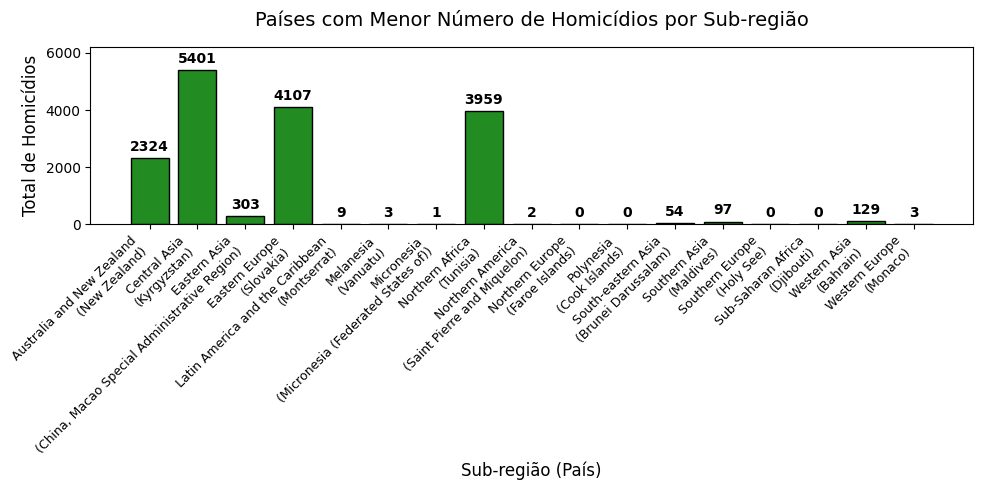

In [70]:
import matplotlib.pyplot as plt

# Filtra os dados para o sexo Total
df_totais = df_limpo[df_limpo['Sex'] == 'Total']
# Agrupa por subregião e país para somar os totais
somas_subregiao = df_totais.groupby(['Subregion', 'Country'])['VALUE'].sum().reset_index()
# Encontra o índice do menor valor dentro de cada subregião
indices_menores = somas_subregiao.groupby('Subregion')['VALUE'].idxmin()
menores_por_subregiao = somas_subregiao.loc[indices_menores].reset_index(drop=True)

# Cria os rótulos combinando a Sub-região com o respectivo País
rotulos_eixo_x = [
    f"{sub}\n({pais})"
    for sub, pais in zip(
        menores_por_subregiao["Subregion"], menores_por_subregiao["Country"]
    )
]

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    rotulos_eixo_x,
    menores_por_subregiao["VALUE"],
    color="forestgreen",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title("Países com Menor Número de Homicídios por Sub-região", fontsize=14, pad=15)
plt.xlabel("Sub-região (País)", fontsize=12)
plt.ylabel("Total de Homicídios", fontsize=12)

plt.ylim(0, menores_por_subregiao["VALUE"].max() * 1.15) # Definindo os limites, superior com folga
plt.xticks(rotation=45, ha="right", fontsize=9)          # Rotaciona os nomes para não sobrepor e ajusta o tamanho da fonte
plt.tight_layout()                                       # Ajusta automaticamente as margens do gráfico
plt.show()                                               # Exibir o gráfico no Colab

5. Quais países com menor número de morte de mulheres?
Filtramos novamente a base para incluir apenas o sexo feminino, agrupamos por país e, desta vez, utilizamos a função nsmallest para buscar os 5 países com os menores registros.

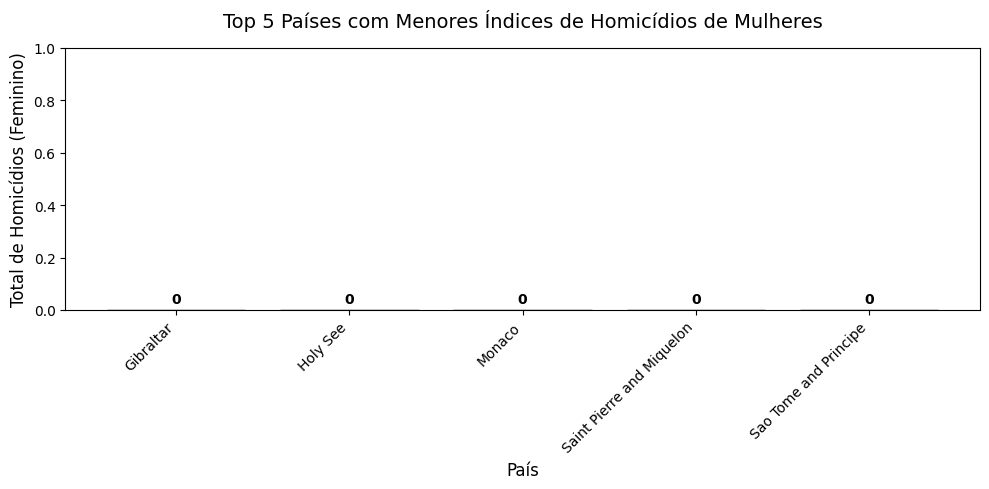

In [71]:
import matplotlib.pyplot as plt

# Filtra os dados para o sexo feminino
df_mulheres = df_limpo[df_limpo['Sex'] == 'Female']
# Agrupa por país e obtém os 5 menores
menores_paises_mulheres = df_mulheres.groupby('Country')['VALUE'].sum().nsmallest(5).reset_index()

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    menores_paises_mulheres["Country"],
    menores_paises_mulheres["VALUE"],
    color="salmon",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title("Top 5 Países com Menores Índices de Homicídios de Mulheres", fontsize=14, pad=15)
plt.xlabel("País", fontsize=12)
plt.ylabel("Total de Homicídios (Feminino)", fontsize=12)

# Como existe paises com valores 0, aqui ajudará na visualização
val_max = menores_paises_mulheres["VALUE"].max()
plt.ylim(0, 1 if val_max == 0 else val_max * 1.15)

plt.xticks(rotation=45, ha="right", fontsize=10) # Rotaciona os nomes dos países para não sobrepor
plt.tight_layout()                               # Ajusta automaticamente as margens do gráfico
plt.show()                                       # Exibir o gráfico no Colab

6. Quais as subregiões com maior número de homicídios?
Lógica semelhante à da Pergunta 3, mas agora agrupando pela coluna 'Subregion' e extraindo apenas os 5 maiores valores.

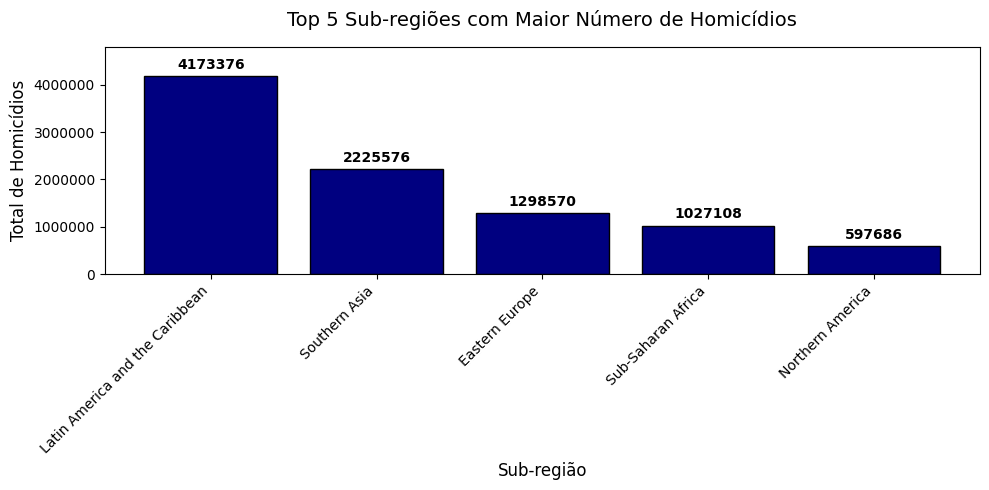

In [72]:
import matplotlib.pyplot as plt

# Agrupa por subregião e obtém os 5 maiores valores (usando o df_totais já filtrado)
subregioes_maiores = df_totais.groupby('Subregion')['VALUE'].sum().nlargest(5).reset_index()

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    subregioes_maiores["Subregion"],
    subregioes_maiores["VALUE"],
    color="navy",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title("Top 5 Sub-regiões com Maior Número de Homicídios", fontsize=14, pad=15)
plt.xlabel("Sub-região", fontsize=12)
plt.ylabel("Total de Homicídios", fontsize=12)

# Formata a visualização do eixo y para não mostrar número científico
plt.ticklabel_format(style="plain", axis="y")

plt.ylim(0, subregioes_maiores["VALUE"].max() * 1.15) # Definindo os limites, superior com folga
plt.xticks(rotation=45, ha="right", fontsize=10)      # Rotaciona os nomes das sub-regiões para não sobrepor
plt.tight_layout()                                    # Ajusta automaticamente as margens do gráfico
plt.show()                                            # Exibir o gráfico no Colab

7. Identifique o país com maior número de homicídios em cada continente em 2020
Primeiro, isolamos os dados do ano de 2020. Depois, agrupamos por Região e País para ter a soma total. Por fim, buscamos o país com o valor máximo (idxmax) dentro de cada Região.

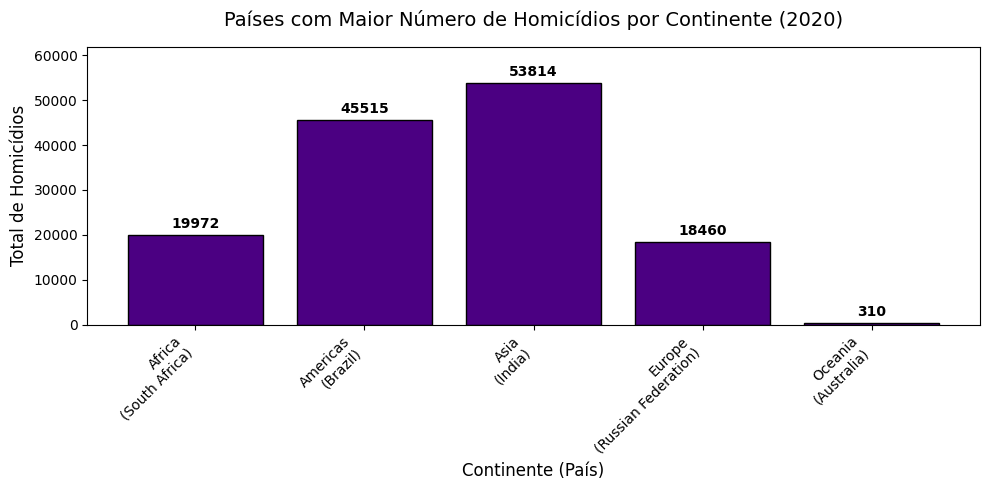

In [73]:
import matplotlib.pyplot as plt

# Filtra os dados para o ano de 2020 e sexo Total
df_2020 = df_limpo[(df_limpo['Year'] == 2020) & (df_limpo['Sex'] == 'Total')]
# Agrupa por região e país para somar os totais
somas_2020 = df_2020.groupby(['Region', 'Country'])['VALUE'].sum().reset_index()
# Encontra o índice do maior valor dentro de cada região/continente
indices_maiores = somas_2020.groupby('Region')['VALUE'].idxmax()
maiores_por_regiao = somas_2020.loc[indices_maiores].reset_index(drop=True)

# Cria os rótulos combinando o Continente (Region) com o respectivo País
rotulos_eixo_x = [
    f"{reg}\n({pais})"
    for reg, pais in zip(
        maiores_por_regiao["Region"], maiores_por_regiao["Country"]
    )
]

# Plotagem em um único gráfico de colunas
plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    rotulos_eixo_x,
    maiores_por_regiao["VALUE"],
    color="indigo",
    edgecolor="black",
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title("Países com Maior Número de Homicídios por Continente (2020)",fontsize=14,pad=15)
plt.xlabel("Continente (País)", fontsize=12)
plt.ylabel("Total de Homicídios", fontsize=12)


plt.ylim(0, maiores_por_regiao["VALUE"].max() * 1.15) # Definindo os limites, superior com folga
plt.xticks(rotation=45, ha="right", fontsize=10)      # Rotaciona os nomes para não sobrepor
plt.tight_layout()                                    # Ajusta automaticamente as margens do gráfico
plt.show()                                            # Exibir o gráfico no Colab

8. Qual o país mais violento para as mulheres em 2021?
Filtramos o ano de 2021 e o sexo feminino. Somamos os valores por país e identificamos aquele com o registro máximo absoluto.

In [81]:
df_mulheres_2021 = df_limpo[(df_limpo['Year'] == 2021) & (df_limpo['Sex'] == 'Female')]
pais_mais_violento_2021 = df_mulheres_2021.groupby('Country')['VALUE'].sum().nlargest(1).reset_index()
pais_mais_violento_2021

,Country,VALUE
0,India,17012.375768


9. Qual o país com maior valor de 'indicador: Victims of intentional homicide'?
Para esta pergunta, utilizamos o DataFrame original completo (sem o filtro exclusivo de 'Counts', caso a métrica do indicador exija visão geral). Procuramos a frase exata na coluna 'Indicator'.

In [80]:
df_indicador = df_limpo[(df_limpo['Indicator'] == 'Victims of intentional homicide') & (df_limpo['Sex'] == 'Total')]
maior_indicador_pais = df_indicador.groupby('Country')['VALUE'].sum().nlargest(1).reset_index()
maior_indicador_pais

,Country,VALUE
0,Brazil,1.560263e+06


10. Qual a média de homicídios no Brasil nos últimos 10 anos?
Consideramos a década mais recente com dados consolidados (2013 a 2022). Filtramos o país 'Brazil', agrupamos os homicídios somados por ano e, ao final, calculamos a média aritmética desses 10 anos.

In [76]:
df_brasil = df_limpo[(df_limpo['Country'] == 'Brazil') & (df_limpo['Sex'] == 'Total') & (df_limpo['Year'] >= 2013) & (df_limpo['Year'] <= 2022)]
media_brasil = df_brasil.groupby('Year')['VALUE'].sum().mean()
tabela_media_brasil = pd.DataFrame({'País': ['Brasil'], 'Média Anual': [media_brasil]})
tabela_media_brasil


,País,Média Anual
0,Brasil,53122.9


Plotagem das questões 8, 9 e 10:

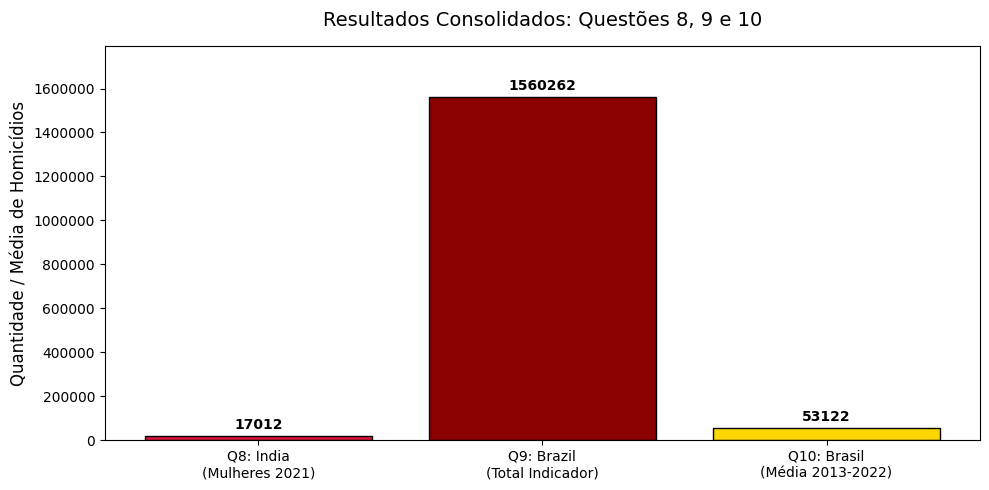

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# <PROCESSAMENTO DOS DADOS>

# 8. País mais violento para mulheres em 2021
df_mulheres_2021 = df_limpo[(df_limpo['Year'] == 2021) & (df_limpo['Sex'] == 'Female')]
q8_res = (df_mulheres_2021.groupby("Country")["VALUE"].sum().nlargest(1).reset_index())
val_q8 = q8_res["VALUE"].values[0]
label_q8 = f"Q8: {q8_res['Country'].values[0]}\n(Mulheres 2021)"

# 9. Maior indicador 'Victims of intentional homicide'
df_indicador = df_limpo[(df_limpo['Indicator'].str.contains('Victims of intentional homicide', na=False, case=False))
                          & (df_limpo['Sex'] == 'Total')]
q9_res = df_indicador.groupby("Country")["VALUE"].sum().nlargest(1).reset_index()
val_q9 = q9_res["VALUE"].values[0]
label_q9 = f"Q9: {q9_res['Country'].values[0]}\n(Total Indicador)"

# 10. Média de homicídios no Brasil (2013 a 2022)
df_brasil = df_limpo[(df_limpo['Country'] == 'Brazil') & (df_limpo['Sex'] == 'Total') & (df_limpo['Year'] >= 2013)
                       & (df_limpo['Year'] <= 2022)]
val_q10 = df_brasil.groupby("Year")["VALUE"].sum().mean()
label_q10 = "Q10: Brasil\n(Média 2013-2022)"

# Consolidando os dados para o gráfico único
labels = [label_q8, label_q9, label_q10]
valores = [val_q8, val_q9, val_q10]

# <PLOTAGEM DO GRÁFICO ÚNICO>

plt.figure(figsize=(10, 5))
grafico_barras = plt.bar(
    labels,
    valores,
    color=["crimson", "darkred", "gold"],
    edgecolor="black"
)

# Adiciona os números em cima de cada coluna
plt.bar_label(grafico_barras, padding=3, fmt="%d", fontsize=10, weight="bold")

# Ajustes de layout e correção de margem superior
plt.title("Resultados Consolidados: Questões 8, 9 e 10", fontsize=14, pad=15)
plt.ylabel("Quantidade / Média de Homicídios", fontsize=12)

# Formata a visualização do eixo y para não mostrar número científico
plt.ticklabel_format(style="plain", axis="y")

plt.ylim(0, max(valores) * 1.15)    # Definindo os limites, superior com folga baseado no maior valor global
plt.xticks(rotation=0, fontsize=10) # Sem rotação pois são apenas 3 colunas bem espaçadas
plt.tight_layout()                  # Ajusta automaticamente as margens do gráfico
plt.show()                          # Exibir o gráfico no Colab

##Definição da Estratégia de Regressão para 2023-2026
Para cumprir a exigência de Machine Learning / Regressão, utilizaremos o modelo de LinearRegression da biblioteca Scikit-Learn.Agruparemos o total global de homicídios por ano (de 2000 a 2022 para ter uma base sólida de treinamento).Treinaremos o modelo usando os Anos como variável independente ($X$) e a Contagem de Homicídios como variável dependente ($y$).Faremos a predição para os anos de 2023, 2024, 2025 e 2026.Por fim, plotaremos um gráfico de linhas para visualizar a tendência histórica unida à previsão futura.

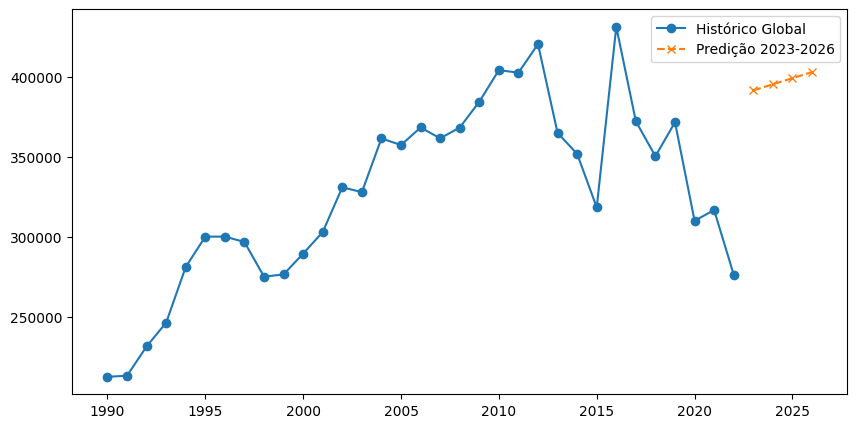

In [78]:
from sklearn.linear_model import LinearRegression

# Preparação dos dados (limitado a 2022 para não quebrar a série)
df_tendencia = df_limpo[(df_limpo['Sex'] == 'Total') & (df_limpo['Year'] <= 2022)].groupby('Year')['VALUE'].sum().reset_index()

X = df_tendencia[['Year']]
y = df_tendencia['VALUE']

modelo = LinearRegression()
modelo.fit(X, y)

# Predição
anos_futuros = pd.DataFrame({'Year': [2023, 2024, 2025, 2026]})
predicoes = modelo.predict(anos_futuros)

# Plotagem
plt.figure(figsize=(10, 5))
plt.plot(df_tendencia['Year'], df_tendencia['VALUE'], label='Histórico Global', marker='o')
plt.plot(anos_futuros['Year'], predicoes, label='Predição 2023-2026', marker='x', linestyle='--')
plt.legend()
plt.show()